In [1]:
import xarray as xr
from glob import glob
from datetime import datetime
import yaml
import sys
sys.path.append('../../')

import plotting

from conf.global_settings import OUTPUT_DIR
from utils.pipeline_utils.file_utils import get_date
from transformations.grid_transformation import Transformation

In [2]:
ds_name = "ATL21_V004_daily"
hemisphere = 'north'
with open(f'conf/ds_configs/{ds_name}.yaml', 'r') as stream:
    config = yaml.load(stream, yaml.Loader)

In [3]:
ds_granules_dir = f'{OUTPUT_DIR}/{ds_name}/harvested_granules/'
ds_granules = glob(f'{ds_granules_dir}/**/*.h5')
if hemisphere:
    ds_granules = [g for g in ds_granules if config['hemi_pattern'][hemisphere] in g]
sample_granule_path = ds_granules[0]
print(sample_granule_path)

/Users/marlis/Developer/ECCO/ecco_output/ATL21_V004_daily/harvested_granules/2022/ATL21-01_20220201012600_06231401_004_01.h5


# Load grid

In [4]:
grids = glob(f'grids/*.nc*')
grids.sort()
f'Available grids: {grids}'

"Available grids: ['grids/ECCO_llc270.nc', 'grids/ECCO_llc90.nc', 'grids/TPOSE.nc', 'grids/polar_stereo_n_25km.nc']"

In [5]:
grid_ds = xr.open_dataset(grids[1])
grid_ds

<xarray.Dataset>
Dimensions:                (tile: 13, j: 90, i: 90)
Coordinates:
  * tile                   (tile) int16 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j                      (j) int16 0 1 2 3 4 5 6 7 ... 82 83 84 85 86 87 88 89
  * i                      (i) int16 0 1 2 3 4 5 6 7 ... 82 83 84 85 86 87 88 89
Data variables:
    XC                     (tile, j, i) float32 ...
    YC                     (tile, j, i) float32 ...
    effective_grid_radius  (tile, j, i) float32 ...
Attributes:
    name:                  ECCO_llc90
    type:                  llc
    geospatial_lat_min:    -89.873055
    geospatial_lat_max:    89.739395
    geospatial_lon_min:    -179.98895
    geospatial_lon_max:    179.98691
    geospatial_lat_units:  degrees_north
    geospatial_lon_units:  degrees_east

# Load sample granule

In [6]:
filename_date_str = get_date(config['filename_date_regex'], sample_granule_path.split('/')[-1])
granule_date = datetime.strptime(filename_date_str, config['filename_date_fmt']).strftime('%Y-%m-%dT%H:%M:%SZ')
T = Transformation(config, sample_granule_path, granule_date)
ds = T.load_file(sample_granule_path)
ds

<xarray.Dataset>
Dimensions:                        (grid_x: 304, grid_y: 448)
Coordinates:
  * grid_x                         (grid_x) float64 -3.838e+06 ... 3.738e+06
  * grid_y                         (grid_y) float64 5.838e+06 ... -5.338e+06
Data variables:
    crs                            int8 ...
    mean_ssha                      (grid_y, grid_x) float32 ...
    mean_weighted_earth_free2mean  (grid_y, grid_x) float32 ...
    mean_weighted_geoid            (grid_y, grid_x) float32 ...
    mean_weighted_geoid_free2mean  (grid_y, grid_x) float32 ...
    mean_weighted_mss              (grid_y, grid_x) float32 ...
Attributes: (12/47)
    short_name:                         ATL21
    level:                              L3B
    description:                        This data set (ATL21) contains daily ...
    Conventions:                        CF-1.7
    contributor_name:                   Alek Petty (alek.a.petty@nasa.gov), R...
    contributor_role:                   Investigator, Investigator, Investiga...
    ...                                 ...
    references:                         http://nsidc.org/data/icesat2/data.html
    project:                            ICESat-2 > Ice, Cloud, and land Eleva...
    instrument:                         ATLAS > Advanced Topographic Laser Al...
    platform:                           ICESat-2 > Ice, Cloud, and land Eleva...
    source:                             Spacecraft
    original_file_name:                 ATL21-01_20220201012600_06231401_004_01

# Make mapping factors

In [7]:
factors = T.make_factors(grid_ds)

# Transformation

In [8]:
field_ds_list = T.transform(grid_ds, factors, ds)

In [9]:
field_ds = field_ds_list[0][0]
field_ds

<xarray.Dataset>
Dimensions:                               (time: 1, tile: 13, j: 90, i: 90,
                                           nv: 2)
Coordinates:
  * time                                  (time) datetime64[ns] 2022-02-01T12...
  * tile                                  (tile) int16 0 1 2 3 4 ... 9 10 11 12
  * j                                     (j) int16 0 1 2 3 4 ... 85 86 87 88 89
  * i                                     (i) int16 0 1 2 3 4 ... 85 86 87 88 89
    XC                                    (tile, j, i) float32 -111.6 ... -111.9
    YC                                    (tile, j, i) float32 -88.24 ... -88.1
    time_bnds                             (time, nv) datetime64[ns] 2022-02-0...
Dimensions without coordinates: nv
Data variables:
    mean_ssha_interpolated_to_ECCO_llc90  (time, tile, j, i) float64 9.969e+3...
Attributes:
    interpolated_grid:            ECCO_llc90
    model_grid_type:              llc
    original_dataset_title:       ATLAS/ICESat-2 L3B Daily and Monthly Gridde...
    original_dataset_short_name:  ATL21_V004
    original_dataset_url:         https://nsidc.org/data/atl21/versions/4
    original_dataset_reference:   https://nsidc.org/sites/default/files/docum...
    original_dataset_doi:         10.5067/ATLAS/ATL21.004
    interpolated_grid_id:         ECCO_llc90
    transformation_version:       1.0
    notes:

# Visualization

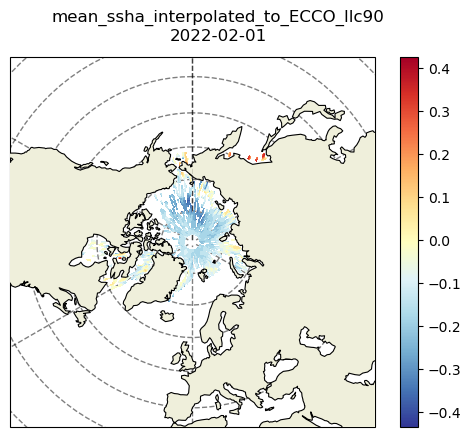

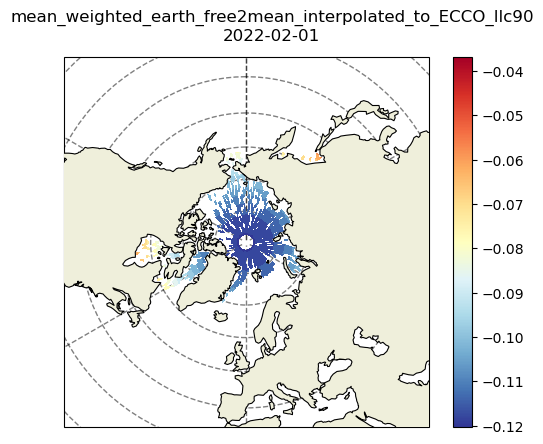

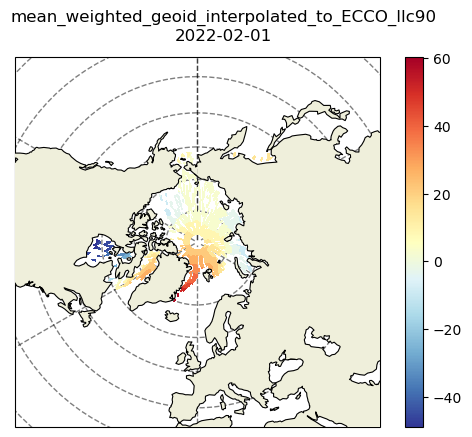

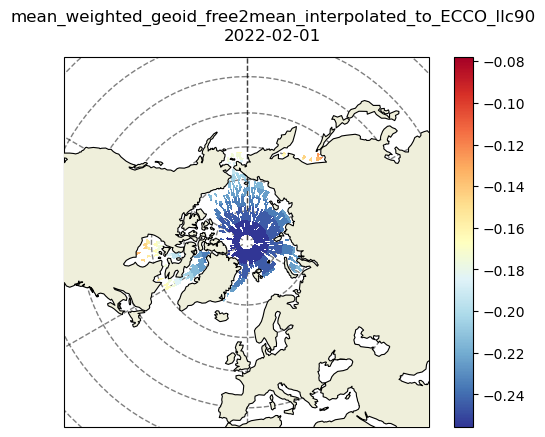

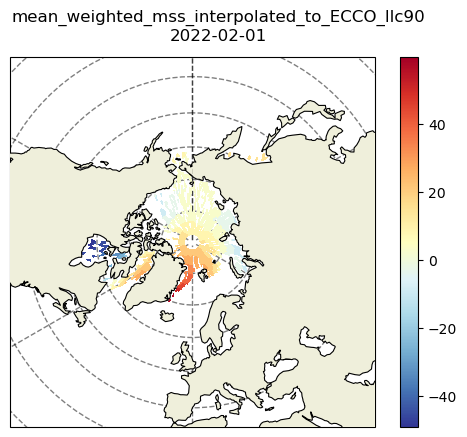

In [10]:
for field_ds in field_ds_list:
    plotting.make_plot(field_ds[0][list(field_ds[0].data_vars)[0]], 'nh')
